# 05 — Explicabilidad del Modelo
## FraudShield-ML

Usamos SHAP para entender que variables impulsan las predicciones del modelo.

### Objetivos
- Crear el SHAP TreeExplainer sobre el modelo LightGBM
- Generar beeswarm plot de importancia global de features
- Analizar una transaccion fraudulenta con waterfall plot
- Guardar el explainer para uso en produccion

### Por que SHAP?
SHAP (SHapley Additive exPlanations) asigna a cada feature su contribucion
exacta a la prediccion — interpretable tanto a nivel global como individual.


## 1. Importaciones

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import shap
import joblib

print("Librerías cargadas")

Librerías cargadas


## 2. Carga del modelo y datos de validacion

In [2]:
PROJECT_ROOT   = Path(".").resolve().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR     = PROJECT_ROOT / "models"

X_train = pd.read_parquet(DATA_PROCESSED / "X_train.parquet")
X_val   = pd.read_parquet(DATA_PROCESSED / "X_val.parquet")
X_test  = pd.read_parquet(DATA_PROCESSED / "X_test.parquet")

y_train = pd.read_parquet(DATA_PROCESSED / "y_train.parquet").squeeze()
y_val   = pd.read_parquet(DATA_PROCESSED / "y_val.parquet").squeeze()
y_test  = pd.read_parquet(DATA_PROCESSED / "y_test.parquet").squeeze()

# Cargar el mejor modelo — LightGBM
model = joblib.load(MODELS_DIR / "LightGBM_best.joblib")

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print("Modelo cargado: LightGBM")

X_train: (413378, 422)
X_val:   (88581, 422)
X_test:  (88581, 422)
Modelo cargado: LightGBM


## 3. Crear SHAP TreeExplainer

TreeExplainer esta optimizado para modelos basados en arboles de decision
como LightGBM, XGBoost y CatBoost.

In [3]:
explainer = shap.TreeExplainer(model)

print("SHAP TreeExplainer creado")

SHAP TreeExplainer creado


## 4. Calcular SHAP values sobre muestra de validacion

In [4]:
# Calculamos sobre una muestra de X_val para que sea rápido
X_sample = X_val.sample(n=2000, random_state=42)

shap_values = explainer(X_sample)

print(f"SHAP values calculados sobre {len(X_sample)} transacciones")
print(f"Shape de shap_values: {shap_values.values.shape}")

SHAP values calculados sobre 2000 transacciones
Shape de shap_values: (2000, 422)


## 5. Recuperar nombres de features del preprocesador

In [5]:
# Cargar el preprocesador
preprocessor = joblib.load(MODELS_DIR / "preprocessor.joblib")

# Recuperar nombres de columnas en el mismo orden que el ColumnTransformer
num_cols  = preprocessor.transformers_[0][2]
cat_low   = preprocessor.transformers_[1][2]
cat_high  = preprocessor.transformers_[2][2]

feature_names = num_cols + cat_low + cat_high

print(f"Total features: {len(feature_names)}")
print(f"Primeras 5: {feature_names[:5]}")

Total features: 422
Primeras 5: ['TransactionAmt', 'card1', 'card2', 'card3', 'card5']


## 6. Beeswarm plot — Importancia global de features

El beeswarm muestra la distribucion de los SHAP values para cada feature.
Cada punto es una transaccion — color indica valor alto (rojo) o bajo (azul).

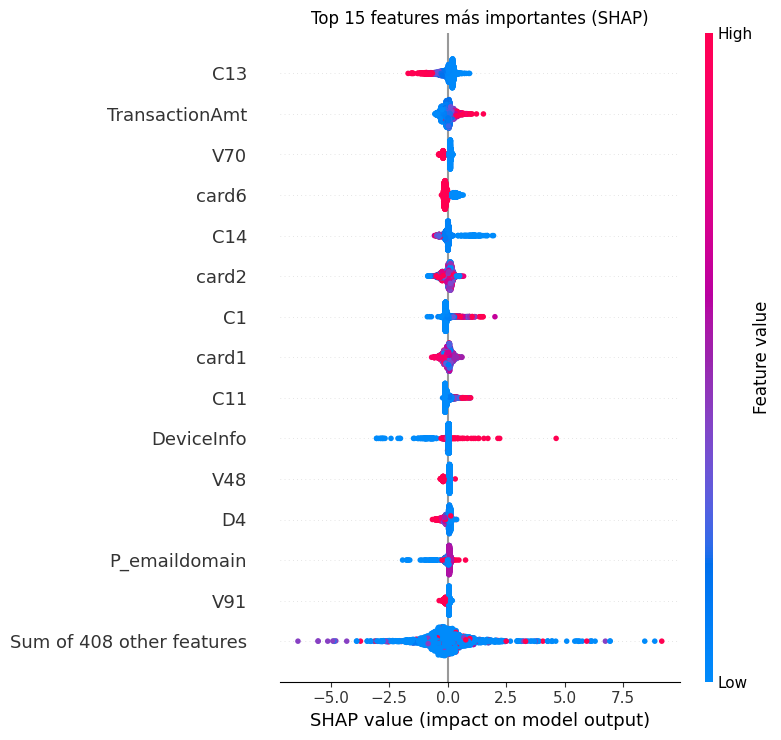

In [6]:
# Asignar nombres de columnas al sample
X_sample.columns = feature_names

# Recalcular SHAP values con los nombres correctos
shap_values = explainer(X_sample)

# Beeswarm con nombres reales
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("Top 15 features más importantes (SHAP)")
plt.tight_layout()
plt.show()

## 7. Waterfall plot — Explicacion de una transaccion fraudulenta

El waterfall muestra como cada feature empuja la prediccion hacia arriba
o hacia abajo para una transaccion especifica.

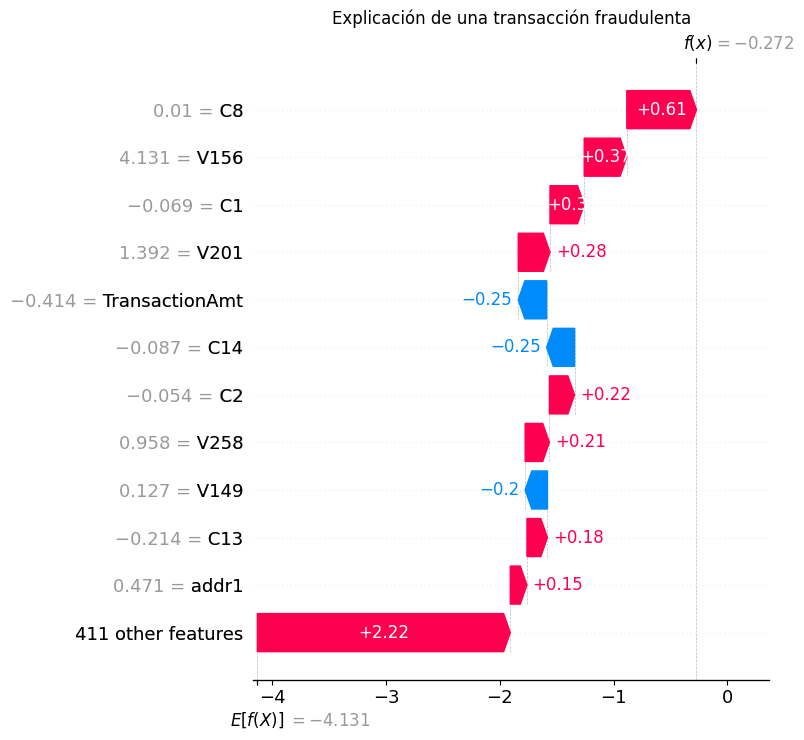

In [7]:
# Elegir una transacción fraudulenta del sample
idx_fraude = y_val.iloc[X_sample.index].reset_index(drop=True)
primera_fraude = idx_fraude[idx_fraude == 1].index[0]

plt.figure()
shap.plots.waterfall(shap_values[primera_fraude], max_display=12, show=False)
plt.title("Explicación de una transacción fraudulenta")
plt.tight_layout()
plt.show()

## 8. Guardar SHAP explainer para produccion

In [8]:
joblib.dump(explainer, MODELS_DIR / "shap_explainer.joblib")
print("SHAP explainer guardado en models/shap_explainer.joblib")

SHAP explainer guardado en models/shap_explainer.joblib
